In [2]:
import time
import numpy as np
from decimal import Decimal, getcontext
from scipy.special import gamma
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from ipywidgets import interact

ModuleNotFoundError: No module named 'ipywidgets'

# Happy $\pi$ Day!

Let's look at some formulae for $\pi$. 

## Archimedes' Polygons
One of the oldest ways to calculate $\pi$ is by bounding a circle between two regular polygons. Here's a function which visualizes the geometry. 

In [164]:
def visualize_archimedes_method(n, show_text=False):
    """
    Inputs n (>= 3) and outputs a visualization of a circle with diameter 1 
    (circumference = pi) with an inscribed and a circumscribed regular n-gon.
    Toggle show_text to display or hide the numerical approximations.
    """
    if n < 3:
        raise ValueError("The number of sides 'n' must be at least 3.")

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)

    # 2. Draw the Circle (Radius = 0.5, Diameter = 1)
    # The true boundary we are approximating is its circumference, exactly pi
    radius = 0.5
    circle = plt.Circle((0, 0), radius, color='black', fill=False, linewidth=2, label='Circle (Circumference = $\\pi$)')
    ax.add_artist(circle)

    # 3. Generate vertices for the polygons
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

    # --- Geometry for the Inscribed Poly ---
    # Radius = 0.5
    inscribed_vertices = np.column_stack([radius * np.cos(angles), radius * np.sin(angles)])

    # --- Geometry for the Circumscribed Poly ---
    # Apothem = 0.5
    # Circumradius of outer polygon = apothem / cos(pi/n)
    circumradius_outer = radius / np.cos(np.pi / n)
    circumscribed_vertices = np.column_stack([
        circumradius_outer * np.cos(angles),
        circumradius_outer * np.sin(angles)
    ])

    # 4. Add the polygons to the plot
    in_poly = patches.Polygon(inscribed_vertices, closed=True, 
                             edgecolor='#1f77b4', facecolor='#1f77b440', 
                             linewidth=2.5, label=f'Inscribed {n}-gon (Lower Bound)')
    
    out_poly = patches.Polygon(circumscribed_vertices, closed=True, 
                              edgecolor='#d62728', facecolor='#d6272840', 
                              linewidth=2.5, linestyle='-', label=f'Circumscribed {n}-gon (Upper Bound)')

    ax.add_patch(out_poly) 
    ax.add_patch(in_poly)

    # 5. Calculate perimeters directly (since Diameter = 1, Perimeter approximates pi)
    # Side length inner = 2 * radius * sin(pi/n) = sin(pi/n)
    perimeter_in = n * np.sin(np.pi / n)
    
    # Side length outer = 2 * radius * tan(pi/n) = tan(pi/n)
    perimeter_out = n * np.tan(np.pi / n)

    # 6. Formatting the plot
    # Adjusted limits to nicely frame the radius=0.5 circle
    ax.set_xlim(-0.8, 0.8)
    ax.set_ylim(-0.8, 0.8)
    
    # Text box for data, controlled by the toggle
    if show_text:
        # ax.legend(loc='lower center', fontsize=10, framealpha=1, bbox_to_anchor=(0.5, -0.15), ncol=1)
        data_text = (
            f"{perimeter_in:.10f} < $\\pi$ < {perimeter_out:.10f}\n"
            f"Error: $\\pm${(perimeter_out - np.pi):.5f}"
        )
        plt.text(-.4, 0.76, data_text, fontsize=11, family='monospace',
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    ax.set_title(f"Archimedes' Method Visualization: n={n}", fontsize=16)
    
    
    plt.show()

Let's look at the simple case of a regular 4-sided polygon, a.k.a. a square.

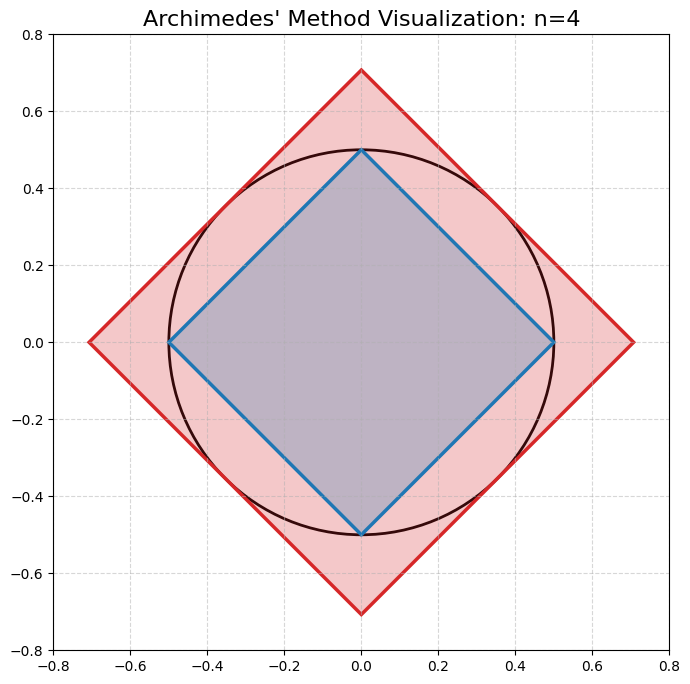

In [165]:
visualize_archimedes_method(4)

$\pi$ is defined to be the circumference of a circle of diameter 1, so we are trying to calculate the perimeter of the central circle in the picture. But circles are curvy, and curvy things are hard to measure precisely. Squares on the other hand are much easier. The perimeter of the inner blue square is surely less than that of the circle, which is in turn clearly less than the perimeter of the outer red square.  $$\text{Perimeter}_{\text{inner}}<\pi<\text{Perimeter}_{\text{outer}}$$
**Inner Square:**

The circle's diameter is the same thing as the small square's diagonal. By the pythagorean theorem, the side length of the small square satifies $s^2+s^2=1^2$, which implies $s={\sqrt{2}\over 2}$. The perimeter of a square is quadruple its side length, so we have shown that $$\sqrt{8}<\pi$$

**Outer Square:**

The large square's side length is the same as the circle's diameter, which is 1. Therefore the outer square has perimeter 4. We now know that $$\sqrt{8}<\pi<4$$
You could whip out a calculator to find that $\sqrt{8}\approx 2.83$, but that would defeat the point! The calculator would probably have a special button for $\pi$, which would make Archimedes too jealous. The calculator's $\pi$ button would be much more accurate than our current approximation. Nevertheless, it would still cut off $\pi$ after a fixed number of decimal places, meaning it is still only an approximation. What if we wanted an wanted to know $\pi$ to even higher accuracy? We don't just want to know what the value of $\pi$ is, we want to know *why* the value of $\pi$ is what is. But I'm getting ahead of myself.

We haven't calculated $\sqrt{8}$, but we can calculate $2.5^2=6.25$ by hand. Then we at least know that $\sqrt{6.25}<\sqrt{8}<\sqrt{9}$, so $2.5<\sqrt{8}<3$. Overall, we have shown (without the need of a calculator) that $\pi$ is somewhere in the range $$2.5<\pi<4$$
This is not too impressive! Trying to draw and measure a circle by hand would probably give a more accurate result. We can't even say for sure whether $\pi>3$ or $\pi<3$. Of course Archimedes wasn't satified with this. But he realized that he could use the same idea to get better accuracy by simply increasing the number of sides of the polygons. 

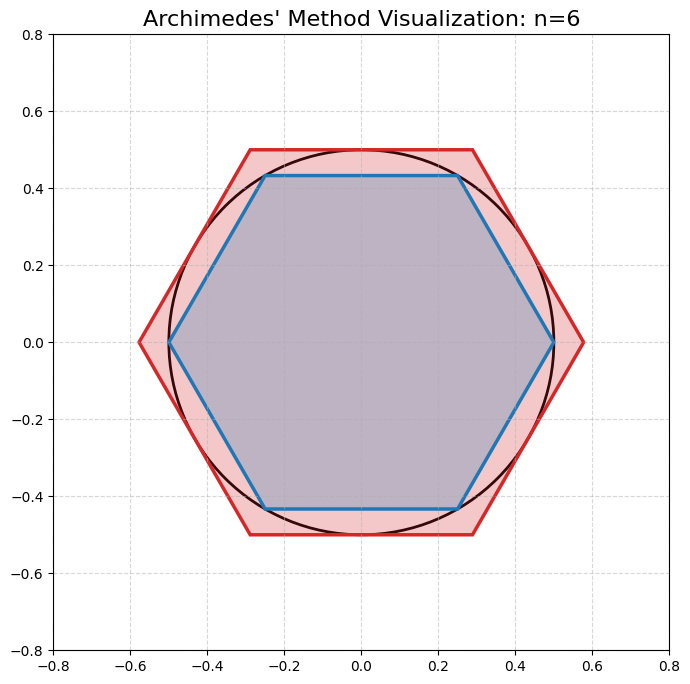

In [166]:
visualize_archimedes_method(6)

If we use hexagons instead of squares, the inner and outer perimeters will end up being closer to $\pi$ simply because there is now less of a gap between the hexagons and circle. The geometry takes a bit longer this time, but hexagons end up improving our estimate to $$3<\pi<\sqrt{12}<3.5$$
So $\pi$ is greater than 3 after all! Thank goodness. 

But we can do better by increasing the number of sides even more. In fact, there is no limit to how good our approximation can get! We can get an extraordinarily good approximation of $\pi$ so long as we are willing and able to do the geometry involved in calculating the side length of a 1000-sided polygon inscribed in a circle of radius $\frac{1}{2}$. 

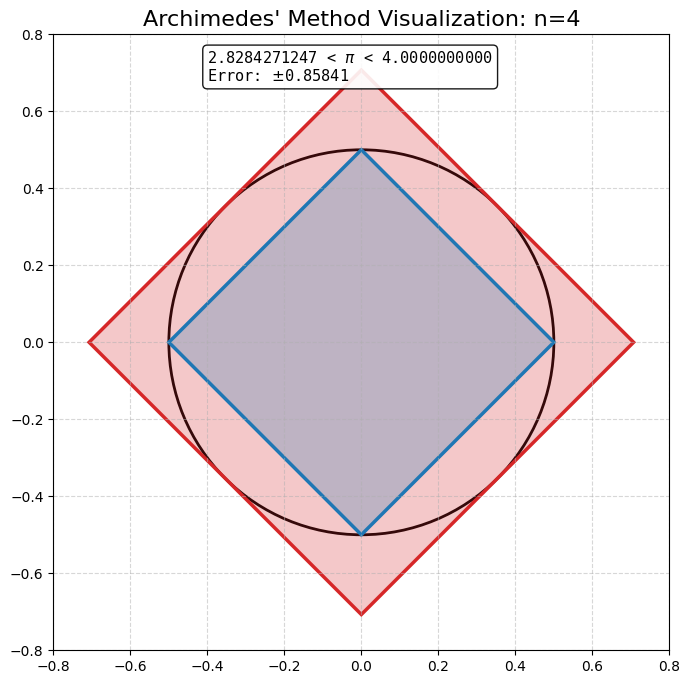

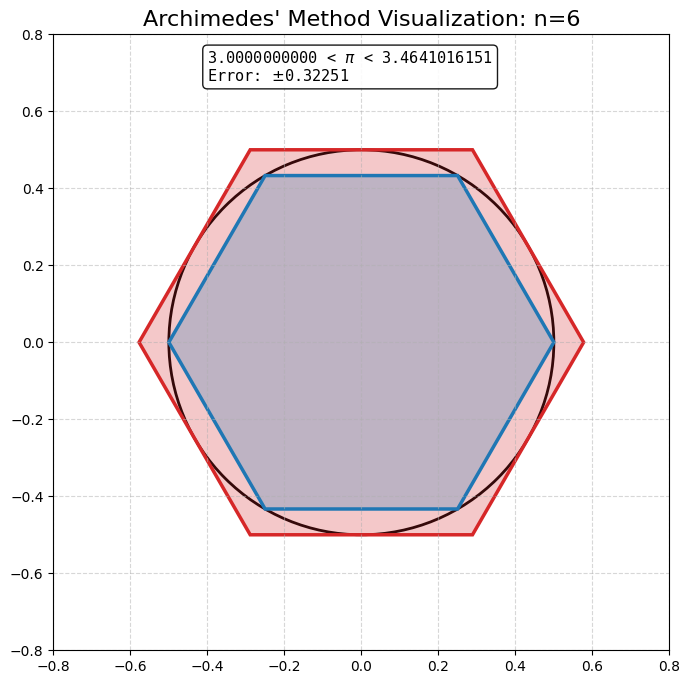

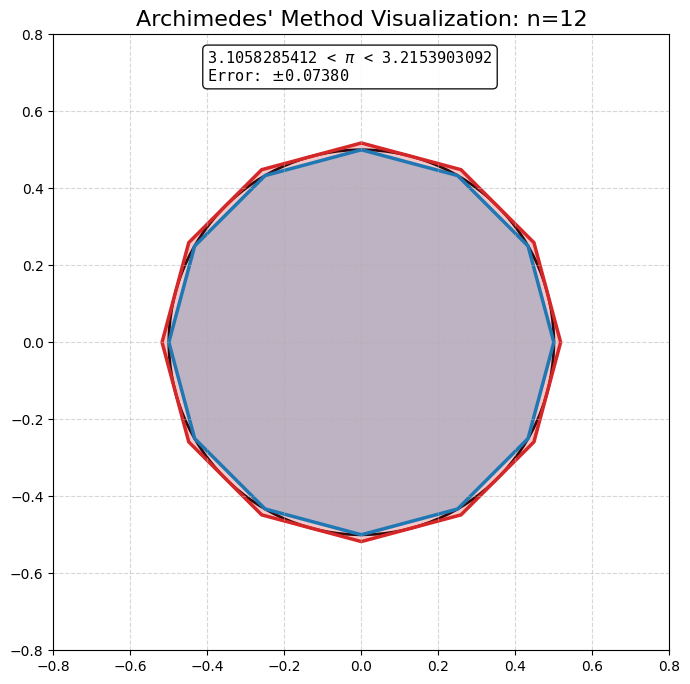

In [167]:
visualize_archimedes_method(4, show_text=True)
visualize_archimedes_method(6, show_text=True)
visualize_archimedes_method(12, show_text=True)

However, if we continue to put ourselves in Archemede's shoes by refusing to use a calculator, the geometry can get quite tedious. Archemedes himself only went to 96 sides, which provided the best known approximation at the time $$\frac{223}{71}<\pi<\frac{22}{7}$$

Keep in mind that those fractions are themselves approximations of square roots that come from doing good ol' fashioned geometry (Pythagorean Theorem). 

Remember before how we got $\sqrt{8}<\pi$? We approximated $\frac{5}{2}<\sqrt{8}$ by hand, which implied that $\frac{5}{2}<\pi$. Well it turns out that the true values you get from using 96-sided polygons happens to be

$$48\sqrt{2-\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{3}}}}}~ < ~\pi ~< ~96\sqrt{\frac{2-\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{3}}}}}{2+\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{3}}}}}}$$
You can understand why Achemedes stopped increasing the polygon sides after calculating *by hand* that $~~~~\frac{223}{71}<48\sqrt{2-\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{3}}}}}~~~~~~$ and $~~~~~~\frac{22}{7}<96\sqrt{\frac{2-\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{3}}}}}{2+\sqrt{2+\sqrt{2+\sqrt{2+\sqrt{3}}}}}}$.

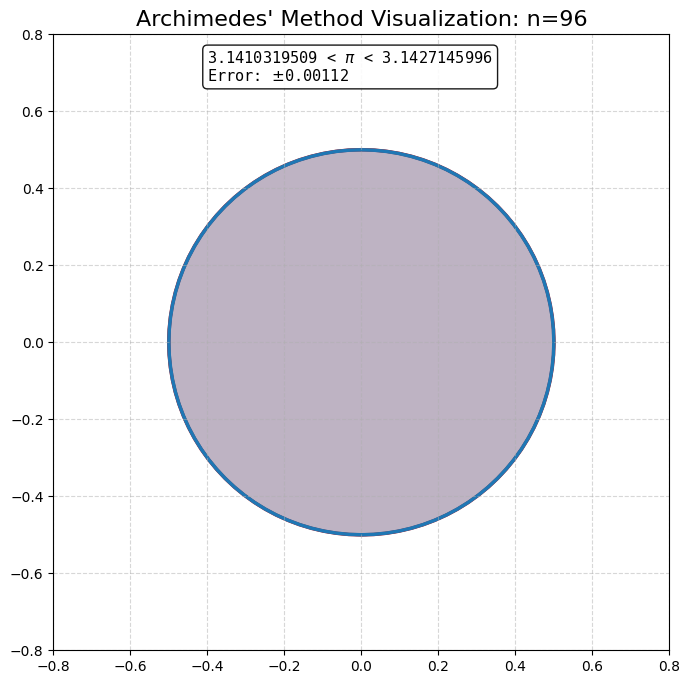

In [168]:
visualize_archimedes_method(96, show_text=True)

At this point, we can't even see the difference between a 96 sided polygon and a circle! And yet, we still only know $\pi$ to 2 decimal places! Amazing how much work went into figuring out that $\pi\approx 3.14\ldots$

Okay, so how can we go further? For an $n$-sided polygon inscribed in a circle, the picture looks like this:

![ngon](https://i.imgur.com/dL5u74P.png)

There are $n$ sides, each of length $\sin\left(\frac{\pi}{n}\right)$, so the total perimeter of the inside polygon is $n\sin\left(\frac{\pi}{n}\right)$. A similar picture shows that the outer perimeter is $n\tan\left(\frac{\pi}{n}\right)\,$. So Archemedes' approach for an $n$-sided polygon gives us the following approximation for $\pi$: $$n\sin\left(\frac{\pi}{n}\right)<\pi<n\tan\left(\frac{\pi}{n}\right)$$ Try plugging in $n=4$ to check against our first square example if you don't believe me!  

It seems like the problem is now harder because we need to compute sine and tangent of $\frac{\pi}{n}$ for a large value of $n$. How can we do this without first knowing what the value of $\pi$ is? Isn't this circular logic? (pun intended) 

Luckily, we can figure out certain values of $\sin\left(\frac{\pi}{n}\right)$ and $\tan\left(\frac{\pi}{n}\right)$ for a few values of $n$ without even knowing what $\pi$ itself is. 

## Generating $\pi$ Randomly

In [ ]:
def approximate_n_ball(dim: int, samples: int) -> float:
    ''' Generate points uniformly in a hypercube
        Returns the proportion that are in the inscribed sphere'''
        
    pts = np.random.uniform(-1, 1, (dim, samples)) # samples num of pts in R^dim
    distance = np.sum(pts**2, axis=0)
    num_sphere_pts = np.sum(distance <= 1)
    n_vol = (num_sphere_pts / samples) * (1 << dim) # volume of unit n-sphere
    
    # n_vol = pi^(n/2) * Gamma(n/2 + 1)^{-1} 
    # ==> 
    # pi = [Gamma(n/2 + 1) * n_vol]^{2/n}
    
    return (gamma(1 + dim/2) * n_vol)**(2/dim)

In [194]:
approximate_n_ball(2, 1000000)

3.143884

In [279]:
def pi_by_coprime(limit: int, samples: int) -> float:
    pairs = np.random.randint(1, limit + 1, size=(2, samples))
    gcds = np.gcd(pairs[0], pairs[1])
    proportion_coprime = np.mean(gcds == 1) # approx 6 / pi^2
    if proportion_coprime:
        return np.sqrt(6 / proportion_coprime)
    return 0

In [295]:
pi_by_coprime(12345, 1000000)

3.1411692499288257